# Day 11 Recap, Resume _About Vectors_ (11 December 2025)

It has been a little over a month since I started my adventure. I am happy because I am busy. I have learned some Python, albeit slowly. I spent some time setting up the blog, but GitHub workflow (Actions) and ChatGPT failed me. I have given up on them and will 

1) Keep doing "core" notebooks (such as this one). They are expected to act like reminders or memory cues. I am applying to my learning what the great mathematician Bill Thurston said of mathematics:
> Mathematics is amazingly compressible: you may struggle a long time, step by step, to work through some process or idea from several approaches. **But once you really understand it and have the mental perspective to see it as a whole, there is often a tremendous mental compression**. You can file it away, recall it quickly and completely when you need it, and use it as just one step in some other mental
process. The insight that goes with this compression is one of the real joys of
mathematics.

2) Keep writing notebooks as blog posts once in a while.

Discussions with ChatGPT have been invaluable. I am still months away from _Thinking in Idiomatic Python_, but I am optimistic about getting there. For now, I am returning to Banesh Hoffmann's book. I will then do Linear Algebra. I will continue exploring Martelli's book and writing [programs](https://github.com/kedarmhaswade/yakk-2/tree/main/programs).

# Chapter 2: Algebraic Notation and Basic Ideas

## 1. Equality and Addition
> Let us agree to say that two vectors, $\vec{U}$ and $\vec{V}$, **are equal if they have equal magnitudes, identical directions, and a common starting point, and represent types of entities that can combine according to the parallelogram law**. If they are _free vectors_ (such as displacement), we need not insist that they have a common starting point:

$$
\begin{equation}
\vec{OA}=\vec{OB}, \text{ or } \vec{\mathbb{U}}=\vec{\mathbb{V}}
\end{equation}
\tag{1.1}
$$

> We shall also use this symbol = in the broader sense of "equivalent to".

> Let us agree to assume that vectors in a given problem or discussion *can combine* unless the contrary is either obvious or else explicitly stated. For example, two displacements can combine, but a force and a displacement cannot.

## Exercise 1.2
If $\vec{\mathbb{U}}$ and $\vec{\mathbb{V}}$ have the same starting point and the same direction, show that the magnitude of their resultant is $\mathbb{U} + \mathbb{V}$.
### My Solution 1.2
Showing something can often be challenging in an open area of mathematics. If we assume the axiomatic method, the axioms need to be stated. In a way, we ask ourselves, "Where do I begin?"

I am going to assume Euclidean geometry in space. Therefore, one axiom is that a plane passes through two given vectors. 

Then, we can consider using the Law of Cosines. 

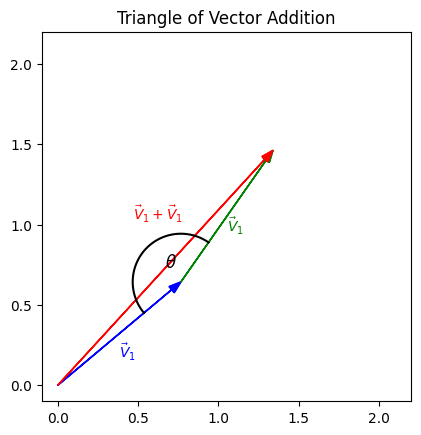

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Two nearly-parallel vectors of equal magnitude
# Let magnitude = 1
angle1 = np.deg2rad(40)    # v1 direction
angle_diff = np.deg2rad(15)  # small difference between the vectors

v1 = np.array([np.cos(angle1), np.sin(angle1)])
v2 = np.array([np.cos(angle1 + angle_diff), np.sin(angle1 + angle_diff)])

# Resultant
R = v1 + v2

# Plot setup
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')

# Draw v1 (tail at origin)
ax.arrow(0, 0, v1[0], v1[1],
         head_width=0.05, length_includes_head=True, color='blue')

# Draw v2 (tail at head of v1)
ax.arrow(v1[0], v1[1], v2[0], v2[1],
         head_width=0.05, length_includes_head=True, color='green')

# Draw resultant R
ax.arrow(0, 0, R[0], R[1],
         head_width=0.05, length_includes_head=True, color='red')

# Draw v1 from origin
ax.arrow(0, 0, v1[0], v1[1],
         head_width=0.05, length_includes_head=True, color='blue')

# Draw v2 from the head of v1
tail2 = v1
ax.arrow(tail2[0], tail2[1], v2[0], v2[1],
         head_width=0.05, length_includes_head=True, color='green')

# Draw resultant
ax.arrow(0, 0, R[0], R[1],
         head_width=0.05, length_includes_head=True, color='red')

# ---- Angle at the joint: nearly pi radians ----
# Draw arc at tail2 (head of v1)
theta = np.linspace(angle1 + np.pi, angle1 + angle_diff, 200)
arc_radius = 0.3
x_arc = tail2[0] + arc_radius * np.cos(theta)
y_arc = tail2[1] + arc_radius * np.sin(theta)

ax.plot(x_arc, y_arc, color='black')

# Label angle: approx pi - angle_diff
obtuse_angle_deg = 180 - np.rad2deg(angle_diff)
mid_theta = (angle1 + np.pi + (angle1 + angle_diff)) / 2

ax.text(tail2[0] + 0.45 * arc_radius * np.cos(mid_theta),
        tail2[1] + 0.45 * arc_radius * np.sin(mid_theta),
        rf"$\theta$",
        fontsize=12)
# Styling
ax.set_xlim(-0.1, 2.2)
ax.set_ylim(-0.1, 2.2)
ax.set_title("Triangle of Vector Addition")

# Labels
ax.text(v1[0]/2, v1[1]/2 - 0.15, r'$\vec{V}_1$', color='blue')
ax.text(v1[0] + v2[0]/2, v1[1] + v2[1]/2 - 0.1, r'$\vec{V}_1$', color='green')
ax.text(R[0]/2-0.2, R[1]/2 + 0.3, r'$\vec{V}_1 + \vec{V}_1$', color='red')

plt.show()


Now, using the Law of Cosines, we can say that $R^2=V_1^2+V_1^2-2V_1V_1\cos\theta=V_1^2+V_1^2-2V_1^2\cos\theta$.

As $\theta$ approaches $\pi^c$, there is only one value that $R^2$ approaches, and that is $2V_1^2-2V_1^2(\cos\pi)=2V_1^2-2V_1^2(-1)=4V_1^2$

Therefore, $R\to V_1+V_1=2 V_1$. Note that $V_1$ is only a real number (scalar), not a vector. We can use the real number rule, $x+x=2\times x=2x\forall x\in\mathbb{R}$. Thus, the resultant is a vector whose magnitude is twice that of each vector being combined.

## 2. Multiplication by Numbers (Scalars)
With various examples, Hoffmann says
> If $h$ is a positive number, we write $h\vec{\mathbb{V}}$ for the vector that is identical with $\vec{\mathbb{V}}$ except that its magnitude is $h$ times that of $\vec{\mathbb{V}}$.

The discussion refers to rational and irrational numbers. With rational numbers (fractions), what $\overrightarrow{\frac{a}{b}\mathbb{V}}\mid a,b\in\mathbb{N}, b\ne 0$ means is clear because with two vectors $\vec{\mathbb{U}},\vec{\mathbb{V}}$ of the same direction (but not necessarily equal magnitudes), we can imagine two vectors $\overrightarrow{a\mathbb{V}}$ and $\overrightarrow{b\mathbb{U}}$ that are "equal" (same direction and magnitude).

Irrationals are trickier. Perhaps we can only approximate a vector $\overrightarrow{\alpha\mathbb{V}}$ where $\alpha$ is an irrational number.

Hoffmann asks a few pretty straightforward exercises. Multiplying a vector by a scalar is also called _scaling_ the vector.

## 3. Subtraction
> Having managed to relate the symbol $+$ to the parallelogram law without doing violence to its usual arithmetical meaning, we wonder whether we can be as successful with the symbol $-$. It turns out that we can!

> If $\overrightarrow{\mathbb{V}}$ is a vector, we define its negative, which we write $\overrightarrow{\mathbb{-V}}$, as a vector identical with it except that it points in the opposite direction. Thus, in Figure 3.1, if U is V turned through $180^\circ$, then $\overrightarrow{\mathbb{U}}=\overrightarrow{\mathbb{-V}}$. Note that $\overrightarrow{\mathbb{V}}$ and $\overrightarrow{\mathbb{-V}}$ have the same magnitude: **the magnitude is always taken to be positive (when it is not zero, of course)**. To consolidate the link between the arithmetical and vectorial uses of the symbol $-$, we define $\overrightarrow{(-h)\mathbb{V}}$ for positive $h$ as $\overrightarrow{h(\mathbb{-V})}$ (where $h\in\mathbb{R}$.
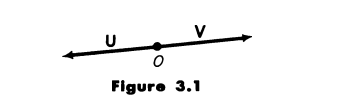

**Introducing Unit Vectors here may be useful.** Also, "time" is considered a scalar, although it has a direction: forward. Thus, when we divide a vector by a number, we get a scaled vector in the same or the opposite direction.

## 4. Speed and Velocity
We learned in grade school that when we divide _distance_ by time (distance traveled per unit time), we get _speed_ (an elusive concept since Zeno of Elea, understood only after Weierstrass formulated calculus in the late nineteenth century). 

Distance is a scalar, and so is Speed. We take _time_ as a scaling factor of two numbers in this case. There is no regard for direction. 

Displacement is a vector, and so is Velocity. Here too, _time_ is a scalar, and we get two vectors that are scaled versions of each other: Displacement and Velocity. Since Displacement is a _free vector_ (the starting point does not matter), so is Velocity.

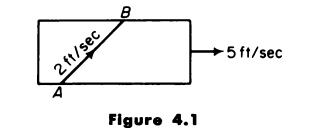

> Figure 4.1 shows a platform with a line AB marked on it. Suppose a point moves uniformly along this line from A to B at 2 ft/sec, and that the platform moves uniformly to the east at 5 ft/sec relative to the ground. Then the point is being subjected to two different velocities simultaneously. **But it does not, therefore, move relative to the ground in two different directions at once.** To say that it did would be to speak nonsense (except, perhaps, if we were talking of quantum phenomena, which we are not). It would remind us of the humorist Stephen Leacock's famous account of the angry man who "flung himself from the room, flung himself upon his horse, and rode madly off in all directions."
> **How does the point actually move**? We can find out by considering what happens in one second. For convenience, let us assume that AB is 2 ft long, so that in one second the point moves from A to B. During this second, the platform moves 5 ft to the east (relative to the ground), and the ends of the line AB drawn on it move to new positions, A', B', that are 5 ft to the east of their original positions, as in Figure 4.2. The moving point travels from A to B' relative to the ground.

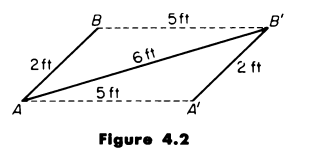

> The distance AB' depends on the angle BAA'; for simplicity, let us assume it is 6 ft. **It is easy to see that the point travels from A to B' in a straight line, with uniform speed relative to the ground**.

## Exercise 4.1 
Prove this. (To get the idea, consider first what happens in, say, 1 second, using similar triangles. Then consider what happens in $t$ seconds.)
### My Solution 4.1
By "this" he means the assertion that point A travels from A to B' in a straight line. As the hint says, we can imagine the situation after 0.5 sec, 0.1 sec, or even a millionth of a second after everything is set in motion. All these triangles, constructed by vectors representing the velocities and their resultants (one along AA', another along AB, and the resultant along AB'), are similar. This means all reincarnations of point B' lie on a straight line. It's almost as if the point has a mind of its own, and it starts moving in the direction AB' right from the word go!

## Exercise 4.3
A train is going at 50 mph due north, and a fly in one of the compartments flies at 20 mph northeast relative to the compartment. Find, by means of an accurate diagram, the actual velocity of the fly relative to the rails.
### My Solution 4.3
It can be shown that the resultant is $55.15$ mph about $55.5^\circ$ north of east.

## Exercise 4.9
A gun mounted on a train is pointed vertically upward. The train moves horizontally due east at 80 mph. And the gun fires a bullet with a muzzle velocity of 80 mph. What is the velocity of the bullet relative to the ground?
### My Solution 4.9
Of course, $80\sqrt{2}$ mph northeast.

## Exercise 4.10
Rain is falling vertically with a speed of $u$ ft/sec. At what angle does it appear to be falling as viewed from a train moving horizontally at $v$ ft/sec?
### My Solution 4.10
This is an often-experienced scenario. You are driving, and it's raining. Your wipers are on. There are signals on the road. As soon as you pick up the speed, the wipers (assuming they are not adaptive, but oscillate at a uniform angular speed) appear to be doing more work. That is, they seem to be wiping more rainwater, even when the rain is uniform. 

I am so glad to see this exercise. I have often wondered about this experience. I reasoned like this: If the rain is falling vertically down at a constant speed, the amount of rainwater must be uniform, _regardless of the car's speed_. 

However, this is _not_ the case. The rain comes _vertically down relative to the ground_. My car moves horizontally relative to the ground (at different speeds; it stops at lights, accelerates, etc.) But we want to estimate the velocity of the falling rain relative to the car.

At first, let the car be stationary. The rainwater is moving $u$ m/s due south relative to both the ground and car because it is stationary (it's "one" with the ground).

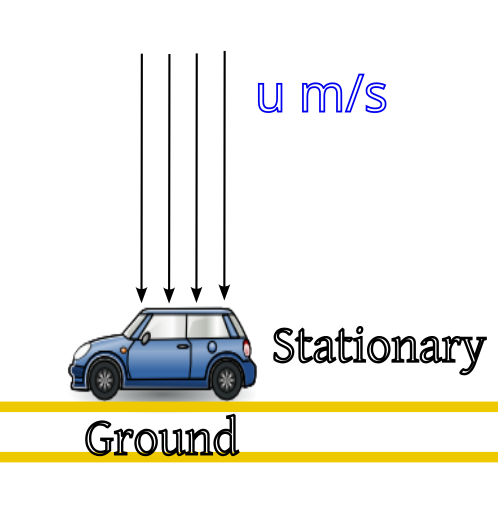

Now, it starts moving due west with a velocity $v$ m/s relative to the ground. This does not affect the velocity of rain relative to the ground. But this does affect the velocity of the rain _perceived_ by the car. 

Since we are inside the car, we want to find the velocities as we perceive them, that is, relative to us! If we are moving $v$ m/s due west relative to the ground, then the ground is moving $v$ m/s due east **relative to us**! 

The picture then becomes like this:
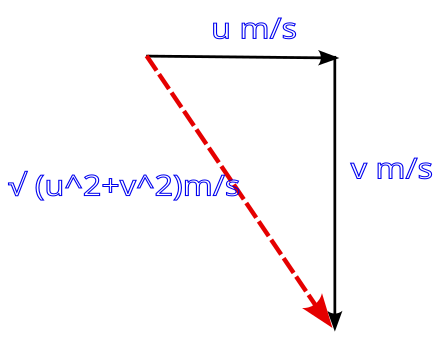

**The car, after picking up speed relative to the ground, indeed perceives that the rain has sped up relative to itself!** The (magnitude of the) velocity of rain as perceived by us inside the car is $\sqrt{u^2+v^2}$, which is larger than both $u$ and $v$. The amount of rainwater collected at the windshield is more, and the wipers have to work harder!

## Exercise 4.11
The wind is blowing steadily from the east at 5 mph. A boat in still water is traveling in a circle, with a constant speed of 5
mph. A pennant (flag) is flying at the top of the mast. Describe in words the way the direction of the pennant changes 
(a) relative to the deck of the boat, and 
(b) relative to the water. 

(It was a situation like this that led the astronomer Bradley to an understanding of the phenomenon of _aberration_, a topic you may find well worth looking into on your own. Note that the velocities in parts (a) and (b) both change.)
### My Solution 4.11
I assume that the radius of the boat's circle is much larger than its dimensions. Thus, when we say that it is traveling in a circle with a constant speed of 5 mph, everything aboard is doing so; the pennant has no circular speed relative to an observer on the deck.

Wind is blowing east to west at 5 mph relative to the still water.

1) Consider the position A1 of the boat. We are on the deck, observing the mast flag. We cannot perceive the boat's tangential velocity because we are on its deck! To us, the flag is just waving to the east, thanks to the wind. And this is the case no matter where the boat is in its orbit.

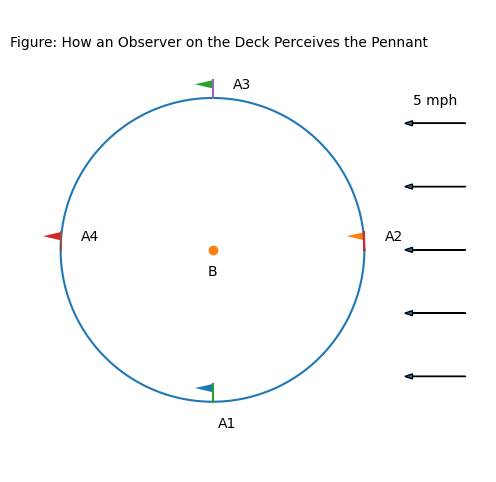

In [41]:
# Thanks to ChatGPT
import matplotlib.pyplot as plt
import numpy as np

# Circle path
theta = np.linspace(0, 2*np.pi, 400)
R = 3
x = R * np.cos(theta)
y = R * np.sin(theta)

plt.figure(figsize=(6,6))
plt.plot(x, y)

# Observer B (center)
plt.plot(0, 0, marker='o', markersize=6)
plt.text(0, -0.3, "B", ha="center", va="top")

# Boat positions and labels in requested order
# A1: bottom (270°), then counterclockwise: 0°, 90°, 180°
angles = [3*np.pi/2, 0, np.pi/2, np.pi]
labels = ["A1", "A2", "A3", "A4"]

for ang, label in zip(angles, labels):
    bx = R * np.cos(ang)
    by = R * np.sin(ang)

    # Mast
    plt.plot([bx, bx], [by, by + 0.35])

    # Flag
    plt.fill(
        [bx, bx - 0.35, bx],
        [by + 0.35, by + 0.27, by + 0.19]
    )

    # Observer label
    if label == "A1":
        # Move below for readability
        plt.text(bx + 0.1, by - 0.3, label, ha="left", va="top")
    else:
        plt.text(bx + 0.4, by + 0.25, label, ha="left", va="center")

    # Tangential velocity direction (unit)
    vx = -np.sin(ang)
    vy =  np.cos(ang)

    # Velocity arrow
    #plt.arrow(
    #    bx, by,
    #    0.8 * vx, 0.8 * vy,
    #    head_width=0.1,
    #    length_includes_head=True
    #)

    # Perpendicular offset for velocity label
    offset = 0.25
    nx = -vy
    ny =  vx

#    plt.text(
#        bx + 0.8 * vx + offset * nx,
#        by + 0.8 * vy + offset * ny,
#        "5 mph",
#        ha="center",
#        va="center"
#    )

# Wind arrows (east to west)
for yy in np.linspace(-2.5, 2.5, 5):
    plt.arrow(5, yy, -1.2, 0, head_width=0.1, length_includes_head=True)

# Wind label
plt.text(4.4, 2.8, "5 mph", ha="center", va="bottom")

# Caption
plt.text(-4, 4, "Figure: How an Observer on the Deck Perceives the Pennant")
plt.axis('equal')
plt.axis('off')
plt.show()


2) To an observer in the still water, it should be a different matter. Consider an observer near A2, but in the water. The boat is moving relative to this observer! She thinks that the flag is still when it is at A1, because it has a tangential velocity equal to the wind's in the opposite direction. Then, it starts waving in a northwestern direction. By the time the boat reaches A2, i.e., the closest to the observer, the flag is moving in the northwest direction. As it leaves A2, it moves less in the northern direction. At A3, it moves fastest directly east. As it leaves A3, it starts moving in a southwestern direction. At A4, it appears to be moving southwest before it starts slowing down. It comes to a stop at A1.